# Jornada de resolución de problemas: 3raJRP 2023 II

**Departamento de Ciencias Físicas, Exactas & Energía / FIDCA**

<!--
Copyright © Angela Villota y Aníbal Sosa.

El contenido textual está licenciado bajo Creative Commons
Attribution-NonCommercial 4.0 International (CC BY-NC 4.0).

El código y la lógica de los notebooks están licenciados bajo
PolyForm Noncommercial License 1.0.0.

Consulte el archivo LICENSE del repositorio para conocer los términos completos.
-->

<img src=http://www.acofi.edu.co/eiei2016/wp-content/uploads/2016/09/Logo-Universidad-ICESI.jpg width="300" height="200" align="center">


**Descripción de la jornada**: En esta jornada usted va a encontrar dos problemas. Debe trabajar en ambos enunciados, completamente el primero y al menos el primer punto del segundo, de forma individual utilizando todos los recursos que usted disponga y sin compartir o recibir ideas de otras personas. La idea central es que elabore sus respuestas o construcciones siguiendo los lineamientos dados a continuación:

1. Escriba con claridad sus propias ideas.
2. Argumente usando lenguaje propio de las matemáticas: geométrico o algebraico, o numérico según sea el caso, cada una de sus respuestas.
3. Respalde donde considere conveniente sus argumentos geométricos y algebraicos con imágenes o applets diseñadas en alguna de las herramientas que hacen parte de la mochila digital.
4.	Resuelva los problemas de manera  autónoma; describiendo estrategias para “atacar” el problema, poniendo a prueba sus soluciones y en lo posible planteando nuevos e “interesantes” interrogantes asociados al problema formulado. Si utiliza un resultado o teorema, este debe ser debidamente citado y si es un resultado ajeno a los estudiados en el curso o del texto guía debe proveer la respectiva demostración.
5. Respuestas sospechosas desde el punto de vista argumentativo o de codificación serán evaluadas en forma oral posteriormente a la finalización de la jornada a mas tardar dos días después de la misma. En estos casos aparecerá un comentario en su cuaderno indicando que debe sustentar el punto. En caso de no sustentar el valor del mismo será 0.0.
6. Debe estar presente en el salón de clase para presentar su jornada o su nota será 0.0.

Valores y vectores propios (dominantes)

**Teorema.** Dada una matriz simétrica $A$ con valores distintos $\lambda_1,\lambda_2,\cdots,\lambda_n$, entonces
$$|\lambda_1|>|\lambda_2|>\cdots>|\lambda_n|.$$
Más aún, sabemos que los vectores propios son ortogonales entre sí.

Este resultado sugiere el siguiente método para encontrar el segundo valor y vector propio dominantes de una matriz $A$.

**Método de deflación.**
Para matrices simétricas podemos construir una extensión del método de las potencias para encontrar el segundo par de valores y vectores propios más dominante siguiendo los pasos dados a continuación. Usted debe hacer una implementación en python de dicho método y justificar algunos pasos o bien argumentando o bien con applets de GeoGebra o ambas cosas.

1.   Utilice el método de las potencias, estudiado en clase, para encontrar el valor propio $\lambda_1$ y el vector propio dominantes $\mathbf{v_1}$ de la matriz simétrica $A=\begin{bmatrix}
1&2\\
2&1
\end{bmatrix}$. Comience con un vector unitario aleatorio $\mathbf{x}$ del tamaño correcto.

2. Multiplicando su vector $\mathbf{x}$ por $A$ lo enviará eventualmente hacia el vector propio dominante. Después de multiplicar, proyecte el vector resultante, $A\mathbf{x}$ sobre el vector propio dominante y encuentre el vector error de proyección $\mathbf{w}$, esencialmente la construcción que hemos hecho en clase. Dibuje su construcción en un solo applet indicando claramente cuáles son los cuatro vectores mencionados. Responda la siguiente pregunta, ¿en cuál subespacio fundamental vive el vector $\mathbf{w}$? Justifique su respuesta.

2. Calcule la aproximación al segundo valor propio dominante como lo hace el método de las potencias.

3. Utilice el vector error de proyección $\mathbf{w}$ como nueva aproximación para el segundo vector propio dominante $\mathbf{v_2}$  ¿Por qué deberíamos hacer esto? ¿Qué encontramos realmente aquí? Normalice el vector $\mathbf{v_2}$.

4. Utilice un criterio de parada para terminar o repetir los pasos 2 a 4.

Tenga en cuenta que el método de deflación es *exactamente igual* que el *método de las potencias*, con la excepción de que *ortogonalizamos* en cada paso. Por lo tanto, cuando escriba su código, espere cambiar solo unas pocas líneas del método de las potencias.

Escriba una función para encontrar el segundo par de valores propios y vectores propios más grande poniendo en práctica el método de deflación. Pruebe su código en la matriz $A$ del enunciado  y compárelo con el comando np.linalg.eig() de Python.

Usted debe finalmente probar su función en matrices simétricas de tamaños 5, 10, 15, 20 y 25. Para ello, necesita  producir una tabla mostrando claramente el error entre el valor y vector propio calculado por su algoritmo y el valor y vector propio del comando eig() de Python, para cada matriz utilizada.

Explique por qué para garantizar que comienza con una matriz simétrica puede usar el siguiente código:

In [ ]:
import numpy as np
N = 5
A = np.random.randn(N,N)
A = np.matrix(A)
S = np.transpose(A) * A # Por qué esta construcción produce siempre una matriz simétrica

## Compresión de imagenes usando la descomposición en valores singulares (SVD)

El código que encuentra a continuación le permite construir una imagen en escala de grises. El valor de cada píxel en una imagen en escala de grises se puede almacenar en una matriz donde cada elemento de la matriz tiene un valor entre 0 (sin intensidad) y 1 (intensidad máxima). Vamos a crear una pequeña matriz que contenga información para una imagen de baja resolución de las letras mayúsculas "SVD".

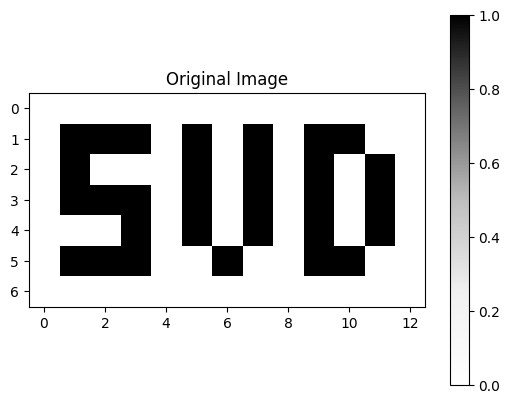

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Define the matrix
A = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0],
    [0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
])

# Color  definition
colors = ["#FFFFFF", "#F0F0F0", "#BDBDBD", "#636363", "#000000"]
color_map = LinearSegmentedColormap.from_list('mycmap', colors)

# Display the color palette
plt.imshow(A, cmap=color_map, interpolation='nearest')
plt.title("Original Image")
plt.colorbar()  # Show color bar
plt.show()


1. **Una aproximación de bajo rango a una imagen.**

  Calcule la SVD de la matriz $A$ de datos y cree una gráfica de los valores singulares. ¿Cúal es el rango máximo de $A$? Debe usar la gráfica de los valores singulares para  elegir la cantidad de componentes que se retendrá para aproximar los datos (la imagen) original. Explique su elección

2. Escriba explícitamente la ecuación que define las aproximaciones de rango uno de una matriz de acuerdo a su elección del punto anterior en términos del rango numérico de $A$. Utilice el código usado en clase para aproximar una imagen utilizando matrices de rango uno y produzca una tabla con 6 imágenes (incluyendo la original) para 5 aproximaciones distintas. Analice la calidad de sus aproximaciones y descríbalo brevemente. ¿Coincide su elección del rango numérico con la mejor aproximación de la imagen original?

3. **Denoising**

Una imagen usualmente está contaminada por algún tipo de ruido. Usted puede utilizar la descomposición de valores singulares y aproximaciones de bajo rango para intentar eliminar el ruido aleatorio que ha dañado una imagen. Los algoritmos de reconstrucción de imágenes utilizados en la práctica van mas alla que el uso de la SVD. Sin embargo, la SVD puede hacer un trabajo razonable al eliminar pequeños ruidos aleatorios de una imagen, haciendo así que ciertas características sean más fáciles de ver.

La SVD debe tener suficientes datos para hacer un buen trabajo, por lo que vamos a  cuadruplicar en el siguiente código la imagen  "SVD" antes de agregar ruido gaussiano aleatorio a los datos. El ruido tiene una desviación estándar igual al 25% del rango de los datos. Los datos ruidosos se muestran como un mapa de calor en el rango [-0,25, 1,25] mediante el uso de una paleta de color que incluye amarillo para valores positivos y rojo para valores menores que 1.

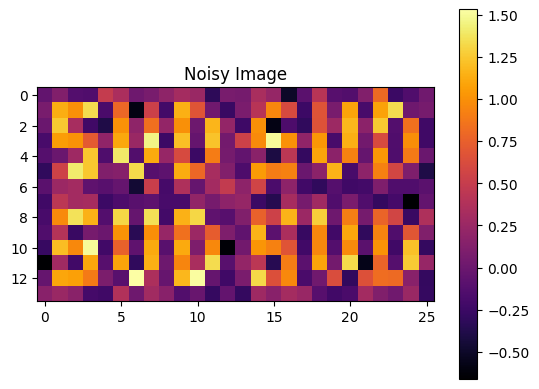

In [ ]:
np.random.seed(12345)

# Duplicate the image
Ad = np.block([[A, A], [A, A]])

# Add Gaussian noise
noise = np.random.normal(0, 0.25, Ad.shape)
A_with_noise = Ad + noise

# Color ramp values
ramp2 = ['#CFFEDA0', '#FFFFFF', '#F0F0F0', '#BDBDBD', '#636363', '#000000', '#3182BD']

# Display the noisy image as a heatmap
plt.imshow(A_with_noise, cmap='inferno', interpolation='nearest')
plt.colorbar()
plt.title('Noisy Image')
plt.show()

Su trabajo ahora consiste en repetir los puntos 1 y 2, escribiendo el respectivo análisis para esta nueva imagen.